# 05 - Comparativo Final: TF-IDF vs Embeddings (MiniLM)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set(style="whitegrid", palette="Set2")

BASELINE_PATH = Path("../models/results_baseline.csv")
EMBEDDINGS_PATH = Path("../models/results_embeddings.csv")

# Carrega resultados do baseline (TF-IDF) e dos embeddings (MiniLM)

In [2]:
baseline = pd.read_csv(BASELINE_PATH)
embeddings = pd.read_csv(EMBEDDINGS_PATH)

baseline["Tipo"] = "TF-IDF"
embeddings["Tipo"] = "Embeddings"

df_all = pd.concat([baseline, embeddings], ignore_index=True)
df_all

,Modelo,Acurácia,F1-Score,AUC,Tipo
0,SVM Linear,0.9602,0.9601,0.9602,TF-IDF
1,Random Forest,0.9611,0.9614,0.9611,TF-IDF
2,SVM (Embeddings),0.8130,0.8069,0.8130,Embeddings


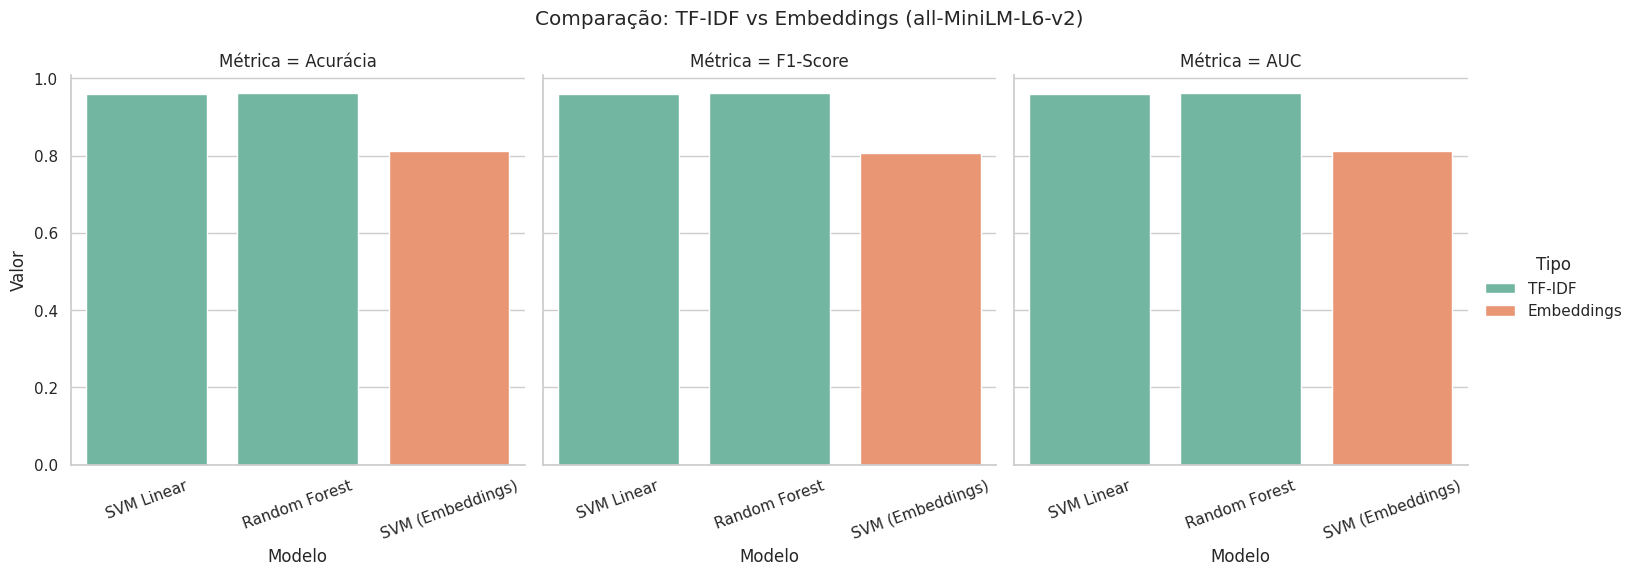

In [3]:
df_melted = df_all.melt(
    id_vars=["Modelo", "Tipo"],
    value_vars=["Acurácia", "F1-Score", "AUC"],
    var_name="Métrica",
    value_name="Valor"
)

g = sns.catplot(
    data=df_melted,
    x="Modelo", y="Valor", hue="Tipo",
    col="Métrica", kind="bar",
    height=5, aspect=1, palette="Set2"
)

g.fig.suptitle("Comparação: TF-IDF vs Embeddings (all-MiniLM-L6-v2)", y=1.05)
g.set_xticklabels(rotation=20)
plt.show()

### Conclusões

- **TF-IDF + SVM/Random Forest** continuam apresentando o melhor desempenho geral,
  especialmente no *Fake.br Corpus*, que é pequeno (~7 mil textos) e lexicalmente homogêneo.
- O modelo **SVM com Embeddings (MiniLM)** obteve F1 ≈ 0.81, indicando bom desempenho semântico,
  mas inferior ao TF-IDF clássico (F1 ≈ 0.96).
- Isso ocorre porque embeddings pré-treinados como o **MiniLM** foram ajustados em inglês
  e requerem *fine-tuning* ou grandes bases para se sobressaírem em português.
- Assim, o TF-IDF se mantém como **baseline interpretável e eficiente**,
  enquanto os embeddings mostram potencial para evoluções futuras (como ajuste fino ou uso de modelos BERT em PT-BR).

